🚀 PaperScout Mock Data Generation Started...

📊 Generating 5,000 mock users...
✅ Generated 5000 users
                                user_id                             email  \
0  0d00648c-3b39-4bf0-b45e-a1ec7d83d7c4           emma.smith@otheredu.com   
1  8717f17e-43ba-44d0-8e69-f044a5ebacc0          james.brown@otheredu.com   
2  4ed9916b-2f9b-40e6-95c3-cce43f294047      maria.williams@oxfordedu.com   
3  747923f5-2e24-4320-b083-3d27bfd35c22         emma.lee@cambridgeedu.com   
4  0890d4f5-69d8-43a7-aca1-58ac36bc6b0b  michael.martinez@stanfordedu.com   

           registration_date user_segment        academic_role  \
0 2025-06-20 20:53:05.125722    Librarian            Librarian   
1 2025-09-14 07:22:38.154911     Industry              Analyst   
2 2024-04-16 17:00:30.812977      Student        Undergraduate   
3 2025-07-18 20:12:48.291813     Academic  Assistant Professor   
4 2024-01-24 02:19:40.066354     Academic              Postdoc   

     research_field           institut

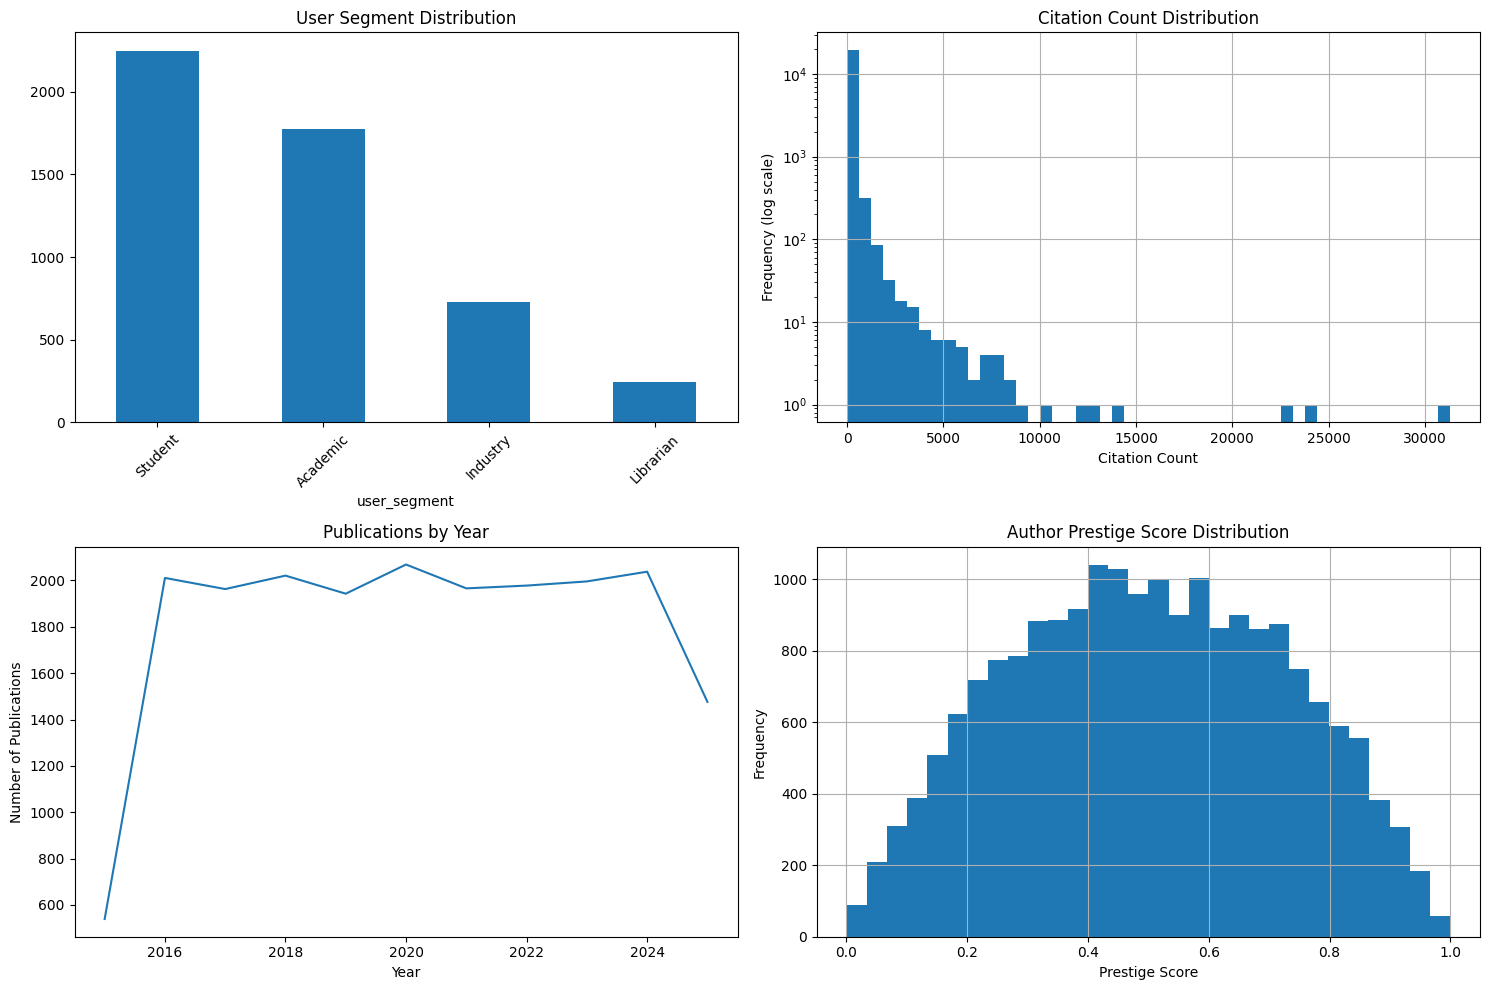

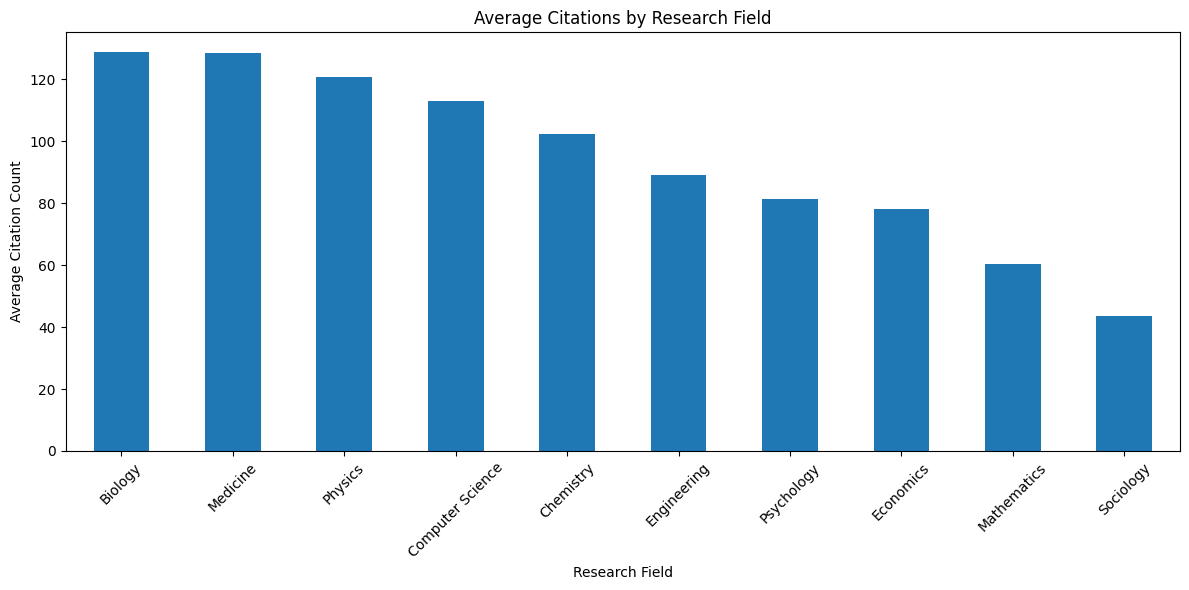


=== ADDITIONAL STATISTICAL INSIGHTS ===

Citation Statistics by Field:
                    mean  median    max
field_of_study                         
Biology           128.78    34.0  12432
Chemistry         102.30    24.0  22721
Computer Science  113.11    27.0  14127
Economics          78.27    20.0   7088
Engineering        89.17    22.0  24270
Mathematics        60.39    16.0   4551
Medicine          128.70    37.0   5842
Physics           120.85    29.0  31300
Psychology         81.51    19.0   8043
Sociology          43.66    14.0    973

Correlation between author prestige and paper quality: 0.837

Recent papers (≤2 years): 5510 papers
Old papers (>5 years): 8477 papers
Average citations - Recent: 35.1, Old: 152.3

=== FILE EXPORT VERIFICATION ===
Users file exists: True - Size: 771740 bytes
Papers file exists: True - Size: 3637914 bytes

🎉 DATA GENERATION COMPLETE!
📊 Generated 5000 users with realistic academic profiles
📚 Generated 20000 papers spanning 10 years of research
💾

In [ ]:
# PaperScout Data Simulation Notebook
# Purpose: Generate realistic mock datasets for users and papers based on the analytics schema

import pandas as pd
import numpy as np
import uuid
from datetime import datetime, timedelta
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

print("🚀 PaperScout Mock Data Generation Started...")

# =============================================================================
# 1. GENERATE MOCK USERS DATA (5,000 users)
# =============================================================================

print("\n📊 Generating 5,000 mock users...")

def generate_users_data(num_users=5000):
    """
    Generate realistic user data with proper distributions for academic profiles
    """
    
    # User segments and their probabilities
    segments = ['Student', 'Academic', 'Industry', 'Librarian']
    segment_probs = [0.45, 0.35, 0.15, 0.05]  # More students and academics
    
    # Academic roles based on segments
    academic_roles = {
        'Student': ['Undergraduate', 'Masters Student', 'PhD Student'],
        'Academic': ['Postdoc', 'Assistant Professor', 'Associate Professor', 'Full Professor', 'Researcher'],
        'Industry': ['Data Scientist', 'Research Scientist', 'Engineer', 'Analyst'],
        'Librarian': ['Librarian', 'Information Specialist']
    }
    
    # Research fields
    research_fields = [
        'Computer Science', 'Biology', 'Physics', 'Chemistry', 'Mathematics',
        'Engineering', 'Medicine', 'Psychology', 'Economics', 'Sociology'
    ]
    
    # Top institutions
    institutions = [
        'Stanford University', 'MIT', 'Harvard University', 'Cambridge University',
        'Oxford University', 'UC Berkeley', 'ETH Zurich', 'University of Toronto',
        'National University of Singapore', 'University of Tokyo',
        'Other University'  # Catch-all for variety
    ]
    
    # Countries with weights for realistic distribution
    countries = ['USA', 'China', 'UK', 'Germany', 'Japan', 'Canada', 'Australia', 
                'France', 'South Korea', 'India', 'Brazil', 'Netherlands']
    country_probs = [0.25, 0.18, 0.08, 0.07, 0.06, 0.05, 0.05, 0.05, 0.04, 0.08, 0.05, 0.04]
    
    users_data = []
    
    for i in range(num_users):
        user_id = uuid.uuid4()
        
        # Generate registration date (more recent registrations are more common)
        days_back = np.random.pareto(2) * 365  # Pareto distribution for realistic signup curve
        registration_date = datetime.now() - timedelta(days=min(days_back, 1095))  # Max 3 years back
        
        # Assign user segment
        segment = np.random.choice(segments, p=segment_probs)
        
        # Assign academic role based on segment
        role_options = academic_roles[segment]
        academic_role = np.random.choice(role_options)
        
        # Research field with some correlation to role
        research_field = np.random.choice(research_fields)
        
        # Institution with weight towards top universities for academics
        if segment == 'Academic':
            institution_probs = [0.15, 0.12, 0.10, 0.08, 0.08, 0.07, 0.05, 0.05, 0.04, 0.03, 0.23]
        else:
            institution_probs = [0.08, 0.07, 0.06, 0.05, 0.05, 0.05, 0.04, 0.04, 0.04, 0.03, 0.49]
        institution = np.random.choice(institutions, p=institution_probs)
        
        # Country distribution
        country = np.random.choice(countries, p=country_probs)
        
        # Subscription tier (most users are free)
        subscription_options = ['free', 'premium', 'enterprise']
        subscription_probs = [0.85, 0.12, 0.03]  # 85% free users
        subscription_tier = np.random.choice(subscription_options, p=subscription_probs)
        
        # Generate email based on name and institution
        first_names = ['john', 'sarah', 'michael', 'emma', 'david', 'lisa', 'robert', 'maria', 
                      'james', 'sophia', 'william', 'olivia', 'richard', 'min', 'wei', 'yuki']
        last_names = ['smith', 'johnson', 'williams', 'brown', 'jones', 'garcia', 'miller', 
                     'davis', 'rodriguez', 'martinez', 'lee', 'wang', 'kim', 'sato', 'singh']
        
        first_name = random.choice(first_names)
        last_name = random.choice(last_names)
        email_domain = institution.lower().replace(' ', '').replace('university', 'edu') + '.com'
        email = f"{first_name}.{last_name}@{email_domain}"
        
        users_data.append({
            'user_id': str(user_id),  # Convert to string for better CSV handling
            'email': email,
            'registration_date': registration_date,
            'user_segment': segment,
            'academic_role': academic_role,
            'research_field': research_field,
            'institution': institution,
            'country': country,
            'subscription_tier': subscription_tier
        })
    
    return pd.DataFrame(users_data)

# Generate users dataframe
users_df = generate_users_data(5000)
print(f"✅ Generated {len(users_df)} users")
print(users_df.head())

# =============================================================================
# 2. GENERATE MOCK PAPERS DATA (20,000 papers)
# =============================================================================

print("\n📚 Generating 20,000 mock papers...")

def generate_papers_data(num_papers=20000):
    """
    Generate realistic paper data with proper academic distributions
    """
    
    # Research fields with different productivity rates
    fields = ['Computer Science', 'Biology', 'Physics', 'Chemistry', 'Mathematics',
             'Engineering', 'Medicine', 'Psychology', 'Economics', 'Sociology']
    field_probs = [0.18, 0.16, 0.12, 0.10, 0.08, 0.14, 0.12, 0.04, 0.04, 0.02]
    
    # Journal/conference names by field
    venues = {
        'Computer Science': ['NeurIPS', 'ICML', 'CVPR', 'AAAI', 'KDD', 'SIGIR', 'WWW'],
        'Biology': ['Nature', 'Science', 'Cell', 'PNAS', 'PLOS Biology', 'Genome Research'],
        'Physics': ['Physical Review Letters', 'Nature Physics', 'Science Advances', 'APL'],
        'Medicine': ['The Lancet', 'JAMA', 'New England Journal of Medicine', 'BMJ']
    }
    
    papers_data = []
    
    for i in range(num_papers):
        paper_id = uuid.uuid4()
        
        # Assign research field
        field = np.random.choice(fields, p=field_probs)
        
        # Generate publication date (last 10 years, more recent papers more common)
        years_back = np.random.uniform(0, 10)
        days_back = years_back * 365
        publication_date = datetime.now() - timedelta(days=days_back)
        
        # Citation count follows a power-law distribution (most papers have few citations)
        # Base citations with field-specific multiplier and recency adjustment
        base_citations = np.random.pareto(1.5) * 20
        field_multiplier = {
            'Medicine': 1.8, 'Biology': 1.6, 'Physics': 1.4, 'Computer Science': 1.3,
            'Chemistry': 1.2, 'Engineering': 1.1, 'Economics': 1.0, 
            'Psychology': 0.9, 'Mathematics': 0.8, 'Sociology': 0.7
        }
        
        # Adjust for paper age (older papers have more time to accumulate citations)
        age_factor = min(years_back / 2, 3)  # Cap at 3x for very old papers
        
        # Recent papers get a boost if they're "hot"
        recency_boost = 1.0
        if years_back < 2:
            # 10% chance of being a "hot" recent paper
            if np.random.random() < 0.1:
                recency_boost = np.random.uniform(2, 5)
        
        citation_count = int(base_citations * field_multiplier[field] * age_factor * recency_boost)
        
        # Author prestige score (0-1) - most authors are in the middle range
        prestige = np.random.beta(2, 2)  # Beta distribution centered around 0.5
        
        # Paper quality score correlates with prestige but has some variance
        quality_score = min(1.0, max(0.0, prestige + np.random.normal(0, 0.15)))
        
        # Novelty score - newer papers tend to have higher novelty
        novelty_base = np.random.beta(2, 3)  # Skewed toward lower novelty
        recency_novelty_boost = max(0, (2 - years_back) / 10)  # Recent papers get novelty boost
        novelty_score = min(1.0, novelty_base + recency_novelty_boost)
        
        # Venue selection
        venue_options = venues.get(field, ['International Conference', 'Journal of ' + field])
        venue = np.random.choice(venue_options)
        
        # Generate realistic title
        title_words = {
            'Computer Science': ['Deep', 'Neural', 'Machine', 'Learning', 'Network', 'Algorithm', 'Data', 'AI'],
            'Biology': ['Genomic', 'Cellular', 'Molecular', 'Genetic', 'Evolutionary', 'Biological'],
            'Physics': ['Quantum', 'Thermodynamic', 'Particle', 'Field', 'Relativistic', 'Atomic']
        }
        
        field_words = title_words.get(field, ['Advanced', 'Novel', 'Experimental', 'Theoretical'])
        title = f"{random.choice(field_words)} {random.choice(['Approach', 'Study', 'Analysis', 'Framework'])} in {field}"
        
        # PDF availability (most papers have PDFs)
        pdf_available = np.random.random() < 0.85
        
        # DOI
        doi = f"10.1234/{venue.lower().replace(' ', '')}.{publication_date.year}.{random.randint(1000, 9999)}"
        
        papers_data.append({
            'paper_id': str(paper_id),  # Convert to string for better CSV handling
            'title': title,
            'publication_date': publication_date,
            'journal_conference': venue,
            'citation_count': max(0, citation_count),  # Ensure non-negative
            'field_of_study': field,
            'author_prestige_score': round(prestige, 3),
            'paper_quality_score': round(quality_score, 3),
            'novelty_score': round(novelty_score, 3),
            'pdf_available': pdf_available,
            'doi': doi
        })
    
    return pd.DataFrame(papers_data)

# Generate papers dataframe
papers_df = generate_papers_data(20000)
print(f"✅ Generated {len(papers_df)} papers")
print(papers_df.head())

# =============================================================================
# 3. DATA VALIDATION AND STATISTICS
# =============================================================================

print("\n🔍 Validating data distributions...")

print("\n=== USERS DATA SUMMARY ===")
print(users_df.describe(include='all'))
print(f"\nUser Segment Distribution:")
print(users_df['user_segment'].value_counts())
print(f"\nSubscription Tier Distribution:")
print(users_df['subscription_tier'].value_counts())

print("\n=== PAPERS DATA SUMMARY ===")
print(papers_df.describe(include='all'))
print(f"\nField of Study Distribution:")
print(papers_df['field_of_study'].value_counts())

# Check for data quality issues
print("\n=== DATA QUALITY CHECKS ===")
print(f"Negative citation counts: {(papers_df['citation_count'] < 0).sum()}")
print(f"Null values in users: {users_df.isnull().sum().sum()}")
print(f"Null values in papers: {papers_df.isnull().sum().sum()}")
print(f"Duplicate emails: {users_df['email'].duplicated().sum()}")
print(f"Duplicate DOIs: {papers_df['doi'].duplicated().sum()}")

print("\n💾 Exporting data to CSV files...")
users_csv_path = 'mock_users.csv'
users_df.to_csv(users_csv_path, index=False)
print(f"✅ Users data exported to {users_csv_path}")
papers_csv_path = 'mock_papers.csv'
papers_df.to_csv(papers_csv_path, index=False)
print(f"✅ Papers data exported to {papers_csv_path}")

print("\n📈 Generating additional insights...")
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    users_df['user_segment'].value_counts().plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('User Segment Distribution')
    axes[0,0].tick_params(axis='x', rotation=45)
    papers_df['citation_count'].hist(bins=50, ax=axes[0,1])
    axes[0,1].set_title('Citation Count Distribution')
    axes[0,1].set_yscale('log') 
    axes[0,1].set_xlabel('Citation Count')
    axes[0,1].set_ylabel('Frequency (log scale)')
    papers_df['publication_date'].dt.year.value_counts().sort_index().plot(kind='line', ax=axes[1,0])
    axes[1,0].set_title('Publications by Year')
    axes[1,0].set_xlabel('Year')
    axes[1,0].set_ylabel('Number of Publications')
    papers_df['author_prestige_score'].hist(bins=30, ax=axes[1,1])
    axes[1,1].set_title('Author Prestige Score Distribution')
    axes[1,1].set_xlabel('Prestige Score')
    axes[1,1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 6))
    field_citations = papers_df.groupby('field_of_study')['citation_count'].mean().sort_values(ascending=False)
    field_citations.plot(kind='bar')
    plt.title('Average Citations by Research Field')
    plt.xlabel('Research Field')
    plt.ylabel('Average Citation Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("Matplotlib not available for visualizations")
except Exception as e:
    print(f"Visualization error: {e}")
    print("Proceeding without visualizations...")

print("\n=== ADDITIONAL STATISTICAL INSIGHTS ===")

print("\nCitation Statistics by Field:")
citation_stats = papers_df.groupby('field_of_study')['citation_count'].agg(['mean', 'median', 'max']).round(2)
print(citation_stats)
correlation = papers_df['author_prestige_score'].corr(papers_df['paper_quality_score'])
print(f"\nCorrelation between author prestige and paper quality: {correlation:.3f}")
current_year = datetime.now().year
papers_df['paper_age'] = current_year - papers_df['publication_date'].dt.year
recent_papers = papers_df[papers_df['paper_age'] <= 2]
old_papers = papers_df[papers_df['paper_age'] > 5]

print(f"\nRecent papers (≤2 years): {len(recent_papers)} papers")
print(f"Old papers (>5 years): {len(old_papers)} papers")
print(f"Average citations - Recent: {recent_papers['citation_count'].mean():.1f}, Old: {old_papers['citation_count'].mean():.1f}")

import os
print("\n=== FILE EXPORT VERIFICATION ===")
print(f"Users file exists: {os.path.exists(users_csv_path)} - Size: {os.path.getsize(users_csv_path) if os.path.exists(users_csv_path) else 0} bytes")
print(f"Papers file exists: {os.path.exists(papers_csv_path)} - Size: {os.path.getsize(papers_csv_path) if os.path.exists(papers_csv_path) else 0} bytes")

print("\n🎉 DATA GENERATION COMPLETE!")
print(f"📊 Generated {len(users_df)} users with realistic academic profiles")
print(f"📚 Generated {len(papers_df)} papers spanning 10 years of research")
print(f"💾 Files saved: 'mock_users.csv' and 'mock_papers.csv'")
print(f"📈 Data follows realistic academic distributions (power-law citations, field-specific patterns)")

print("\n=== SAMPLE USER DATA ===")
print(users_df[['user_id', 'email', 'user_segment', 'research_field']].head(3))

print("\n=== SAMPLE PAPER DATA ===")
print(papers_df[['paper_id', 'title', 'citation_count', 'field_of_study']].head(3))

print("\n✅ Mock data generation successful! Files are ready for analysis.")